# SVGD

Implements Algorithm 1 "Bayesian Inference via Variational Gradient Descent" 

In [196]:
import jax.numpy as np
import jax.scipy.stats.multivariate_normal as mvn
import matplotlib.pyplot as plt
import numpy as standard_np
from jax import value_and_grad, grad, vmap
p = standard_np.random.rand(200,2)*5
p = p[np.argsort(p[:,0]),:]

In [197]:
def plotdata(data):
    #plt.hexbin(data[:,0],data[:,1],gridsize=40,extent=(0,5,0,5))
    plotx = standard_np.linspace(0, 5, 40)
    ploty = standard_np.linspace(0, 5, 40)
    plotX, plotY = standard_np.meshgrid(plotx, ploty)
    #[prob(np.array([x,y])) for x,y in zip(X,Y)]
    plotZ = prob(standard_np.array([plotX.flatten(),plotY.flatten()]).T).reshape(len(plotx),len(ploty))
    plt.contour(plotX, plotY, plotZ)
    plt.scatter(data[:,0],data[:,1],1)
    plt.xlim([0,5])
    plt.ylim([0,5])

def prob(x):
    return (mvn.pdf(x,np.array([2,2]),np.array([[1,-0.8],[-0.8,1]]))+mvn.pdf(x,np.array([3.5,4]),np.array([[0.5,0],[0,0.5]])))/2

def logprob(x):
    return np.log(prob(x))
    
def k(x,xprime):
    return 100*np.exp(-np.sum((x[:,None]-xprime[None,:])**2/0.01,2))
def ksingle(x,xprime):
    return 100*np.exp(-np.sum((x-xprime)**2/0.01))

In [198]:
#takes 2.29s vs 56.8ms
#[grad(logprob)(p_i) for p_i in p]
for it in range(500):
    K = k(p,p)
    g = vmap(grad(logprob),0)(p)
    gk = vmap(lambda p2: vmap(grad(lambda p1: ksingle(p1,p2)))(p))(p)
    p+=(K@g+np.sum(gk,0))*0.001

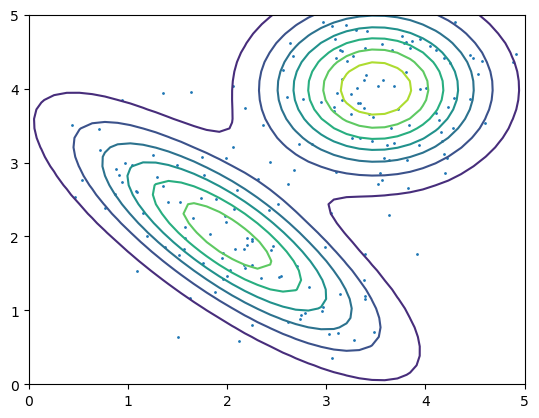

In [199]:
plotdata(p)

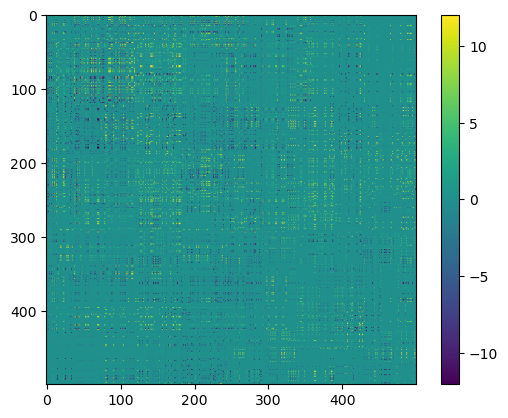

In [144]:
plt.imshow(np.sum(gk,(2)))
plt.colorbar()

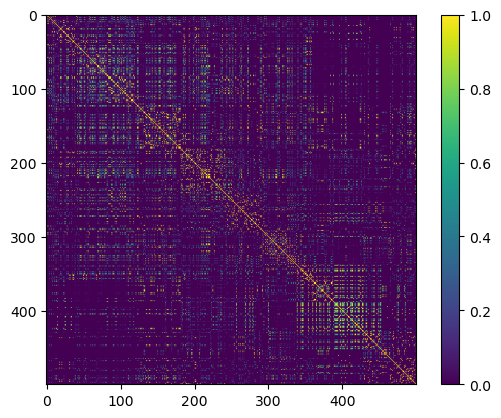

In [145]:
plt.imshow(k(p,p))
plt.colorbar()

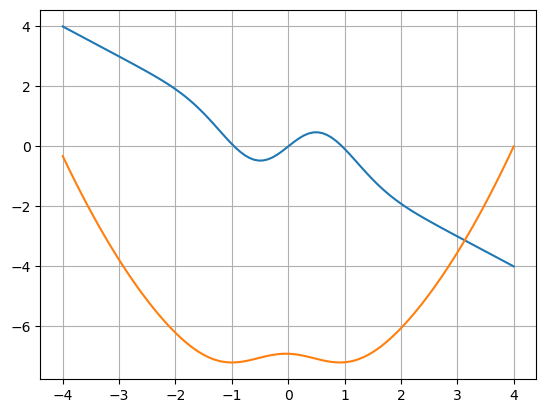

In [179]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4,4,100)
g = 10*np.exp(-x**2)*x/4-x
plt.plot(x,g)
plt.plot(x,-np.cumsum(g)*(x[1]-x[0]))
plt.grid()